In [117]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [118]:
torch.get_default_dtype()

torch.float64

# Deterministic Neural Network

In [119]:
transform = transforms.ToTensor()

full_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

full_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Keep only digits 0 and 1
train_indices = [i for i, (_, y) in enumerate(full_train) if y in [0, 1]]
test_indices = [i for i, (_, y) in enumerate(full_test) if y in [0, 1]]

train_dataset = Subset(full_train, train_indices)
test_dataset = Subset(full_test, test_indices)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 12665
Test size: 2115


In [120]:
torch.nn.init.trunc_normal_

class DeterministicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 600)
        self.fc2 = nn.Linear(600, 600)
        self.fc3 = nn.Linear(600, 1)

        self._init_weights()

    def _init_weights(self):
        sigma = 0.04
        for m in [self.fc1, self.fc2, self.fc3]:
            nn.init.trunc_normal_(m.weight, mean=0.0, std=sigma, a=-2*sigma, b=2*sigma)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)
    
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().unsqueeze(1)
            
            preds = model(x)
            predicted = (preds > 0.5).float()
            
            correct += (predicted == y).sum().item()
            total += y.size(0)
    
    return correct / total

    
model = DeterministicNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss() #Binary Cross-entropy Loss
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device, dtype=x.dtype).unsqueeze(1)
        
        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    train_acc = evaluate(model, train_loader)
    test_acc = evaluate(model, test_loader)
    
    print(f"Epoch {epoch+1}")
    print(f"Loss: {total_loss/len(train_loader):.4f}")
    print(f"Train acc: {train_acc:.4f}")
    print(f"Test acc: {test_acc:.4f}")
    print("-"*30)

det_model = model

Epoch 1
Loss: 0.0333
Train acc: 0.9994
Test acc: 0.9991
------------------------------
Epoch 2
Loss: 0.0020
Train acc: 0.9994
Test acc: 0.9995
------------------------------
Epoch 3
Loss: 0.0017
Train acc: 0.9999
Test acc: 0.9995
------------------------------
Epoch 4
Loss: 0.0006
Train acc: 0.9998
Test acc: 0.9995
------------------------------
Epoch 5
Loss: 0.0007
Train acc: 1.0000
Test acc: 0.9995
------------------------------
Epoch 6
Loss: 0.0002
Train acc: 1.0000
Test acc: 0.9995
------------------------------
Epoch 7
Loss: 0.0012
Train acc: 0.9997
Test acc: 0.9995
------------------------------
Epoch 8
Loss: 0.0028
Train acc: 0.9994
Test acc: 0.9986
------------------------------
Epoch 9
Loss: 0.0002
Train acc: 1.0000
Test acc: 0.9995
------------------------------
Epoch 10
Loss: 0.0001
Train acc: 1.0000
Test acc: 0.9995
------------------------------


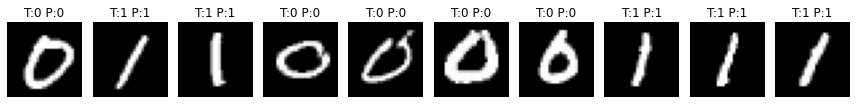

In [121]:
#Test to show that it works          
def show_images_with_predictions(model, dataset, num_images=10):
    model.eval()
    plt.figure(figsize=(12, 3))
   
    for i in range(num_images):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]
        
        x = img.unsqueeze(0).to(device)
        with torch.no_grad():
            prob = model(x).item()
            pred = int(prob > 0.5)
        
        plt.subplot(1, num_images, i+1)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.title(f"T:{label} P:{pred}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_images_with_predictions(det_model, test_dataset, num_images=10)


## Some Functions to compute the PAC Bound via KL inversion

In [24]:
## Bissection method to compute the little KL inverse q given q_hat and c

def binary_kl(p, q, eps=1e-12):
    p = torch.clamp(p, eps, 1 - eps)
    q = torch.clamp(q, eps, 1 - eps)
    return p * torch.log(p / q) + (1 - p) * torch.log((1 - p) / (1 - q))

@torch.no_grad()
def kl_inverse_upper(qhat, c, tol=1e-10, max_iter=80):
    """
    Returns the largest q in [qhat, 1) such that kl(qhat || q) <= c.
    Assumes q >= qhat.
    """
    qhat = torch.clamp(qhat, 0.0, 1.0)
    c = torch.clamp(c, 0.0)

    # Special-case qhat = 0 or 1 (closed forms, avoids numerical weirdness)
    if float(qhat) == 0.0:
        # kl(0||q) = -log(1-q) <= c  =>  q <= 1-exp(-c)
        return torch.clamp(1.0 - torch.exp(-c), 0.0, 1.0 - 1e-12)
    if float(qhat) == 1.0:
        # kl(1||q) = -log(q) <= c  =>  q >= exp(-c), but we want upper bound in [qhat,1)
        return torch.tensor(1.0 - 1e-12, device=qhat.device)

    lo = qhat.clone()
    hi = torch.ones_like(qhat) * (1.0 - 1e-12)

    # Invariant: feasible region is [qhat, lo], infeasible is [hi, 1)
    for _ in range(max_iter):
        mid = (lo + hi) / 2.0
        val = binary_kl(qhat, mid)

        if float(val) <= float(c):
            lo = mid  # mid is feasible; push up
        else:
            hi = mid  # mid infeasible; push down

        if float(hi - lo) < tol:
            break

    return lo

#Compute q_hat with Monte Carlo approx
@torch.no_grad()
def empirical_gibbs_risk_01(model, loader, mc_samples=10, device="cuda"):
    """
    Estimates \hat L(Q) = E_{w~Q}[ 1(f_w(x) != y) ] on the dataset in loader.
    We approximate the expectation over w via Monte Carlo sampling.
    """
    model.eval()
    total = 0
    wrong = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        bs = y.numel()
        total += bs

        # average 0-1 error over MC samples of weights
        batch_wrong = 0.0
        for _ in range(mc_samples):
            probs = model(x).view(-1)          # sigmoid outputs in [0,1]
            pred = (probs > 0.5).long()
            batch_wrong += (pred != y).float().sum().item()

        wrong += batch_wrong / mc_samples

    return wrong / total

@torch.no_grad()
def pac_bayes_kl_bound(model, train_loader, n_train, delta=0.05, mc_samples=10, device="cuda"):
    # empirical Gibbs risk on training sample
    qhat = torch.tensor(empirical_gibbs_risk_01(model, train_loader, mc_samples=mc_samples, device=device),
                        device=device, dtype=torch.float32)

    # KL(Q||P) from your stochastic net
    kl_qp = model.kl_divergence().detach()

    # RHS constant
    c = (kl_qp + math.log(n_train / delta)) / (n_train - 1)

    # invert binary kl to get upper bound on true risk
    ub = kl_inverse_upper(qhat, c)

    return {
        "qhat_empirical_gibbs_risk": float(qhat.detach().cpu()),
        "kl_qp": float(kl_qp.detach().cpu()),
        "c": float(c.detach().cpu()),
        "bound_true_gibbs_risk": float(ub.detach().cpu()),
    }

# Stochastic Neural Network with Isotropic Covariance

In [122]:
class StochasticLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_std=1.0, init_rho=-6.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_std = float(prior_std)

        # Posterior parameters (learned)
        self.mu_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.rho_weight = nn.Parameter(torch.empty(out_features, in_features))

        self.mu_bias = nn.Parameter(torch.empty(out_features))
        self.rho_bias = nn.Parameter(torch.empty(out_features))

        # Init (will be overwritten when we "load" from deterministic net)
        nn.init.normal_(self.mu_weight, mean=0.0, std=0.01)
        nn.init.constant_(self.rho_weight, init_rho)
        nn.init.zeros_(self.mu_bias)
        nn.init.constant_(self.rho_bias, init_rho)
        
    def sample_params(self):
        sigma_w = torch.exp(self.rho_weight)
        sigma_b = torch.exp(self.rho_bias)

        eps_w = torch.randn_like(sigma_w)
        eps_b = torch.randn_like(sigma_b)

        w = self.mu_weight + sigma_w * eps_w
        b = self.mu_bias + sigma_b * eps_b
        return w, b

    def forward(self, x):
        w, b = self.sample_params()
        return F.linear(x, w, b)

    def kl_divergence_to_isotropic_gaussian_prior(self):
        """
        KL( N(mu, diag(sigma^2)) || N(0, prior_std^2 I) )
        closed form, summed over all params in this layer.
        """
        prior_var = self.prior_std ** 2

        sigma_w = torch.exp(self.rho_weight)
        sigma_b = torch.exp(self.rho_bias)

        var_w = sigma_w ** 2
        var_b = sigma_b ** 2

        # 0.5 * sum( (var + mu^2)/prior_var - 1 - log(var/prior_var) )
        kl_w = ((var_w + self.mu_weight**2) / prior_var - 1.0 - torch.log(var_w / prior_var)).sum()
        kl_b = ((var_b + self.mu_bias**2) / prior_var - 1.0 - torch.log(var_b / prior_var)).sum()

        return 0.5 * (kl_w + kl_b)

    def load_from_deterministic(self, det_linear: nn.Linear):
        """Initialize posterior mean at deterministic weights, keep rho as-is."""
        with torch.no_grad():
            self.mu_weight.copy_(det_linear.weight.data)
            self.mu_bias.copy_(det_linear.bias.data)
            
            
class StochasticNet(nn.Module):
    def __init__(self, prior_std=1.0, init_rho=-6.0):
        super().__init__()
        self.fc1 = StochasticLinear(28*28, 600, prior_std=prior_std, init_rho=init_rho)
        self.fc2 = StochasticLinear(600, 600, prior_std=prior_std, init_rho=init_rho)
        self.fc3 = StochasticLinear(600, 1,   prior_std=prior_std, init_rho=init_rho)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return torch.sigmoid(x)

    def kl_divergence(self):
        return (
            self.fc1.kl_divergence_to_isotropic_gaussian_prior()
            + self.fc2.kl_divergence_to_isotropic_gaussian_prior()
            + self.fc3.kl_divergence_to_isotropic_gaussian_prior()
        )

    def load_from_deterministic_net(self, det_net: nn.Module):
        self.fc1.load_from_deterministic(det_net.fc1)
        self.fc2.load_from_deterministic(det_net.fc2)
        self.fc3.load_from_deterministic(det_net.fc3)


In [124]:
prior_std = 0.135 #approx e^(-2)
init_rho = -2. # small initial sigma via softplus(rho)

stoch_model = StochasticNet(prior_std=prior_std, init_rho=init_rho).to(device)
stoch_model.load_from_deterministic_net(model) #set the mean to deterministic net
stoch_model.eval()

print("Initialized stochastic posterior around the deterministic solution.")
print("Initial KL(Q||P):", float(stoch_model.kl_divergence().detach().cpu()))

def param_snapshot(model):
    with torch.no_grad():
        mu_norm = torch.norm(model.fc1.mu_weight).item()
        rho_mean = model.fc1.rho_weight.mean().item()
        sigma_mean = torch.exp(model.fc1.rho_weight).mean().item()
    return mu_norm, rho_mean, sigma_mean

print("Before:", param_snapshot(stoch_model))


Initialized stochastic posterior around the deterministic solution.
Initial KL(Q||P): 33428.82155017445
Before: (26.003251393273842, -2.0, 0.13533528323661279)


In [125]:
def evaluate_stochastic(model, loader, mc_samples=5):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            # Average predictions over MC samples
            probs = 0.0
            for _ in range(mc_samples):
                probs = probs + model(x)
            probs = probs / mc_samples

            pred = (probs > 0.5).long().view(-1)
            correct += (pred == y).sum().item()
            total += y.numel()

    return correct / total

train_acc_stoch = evaluate_stochastic(stoch_model, train_loader, mc_samples=1)
test_acc_stoch  = evaluate_stochastic(stoch_model, test_loader,  mc_samples=1)

print("Stochastic Train acc (MC avg):", train_acc_stoch)
print("Stochastic Test  acc (MC avg):", test_acc_stoch)


Stochastic Train acc (MC avg): 0.9481247532570075
Stochastic Test  acc (MC avg): 0.9002364066193853


In [128]:
#Test on a grid to pick the best prior rho
prior_std_grid = [0.1,0.14, 0.20, 0.28, 0.316]
init_rho = -2.0          # try also -3.0 later
mc_bound = 1
n = len(train_dataset)
delta = 0.05

for ps in prior_std_grid:
    m = StochasticNet(prior_std=ps, init_rho=init_rho).to(device)
    m.load_from_deterministic_net(det_model)

    out = pac_bayes_kl_bound(
        m,
        train_loader,
        n,
        delta=delta,
        mc_samples=mc_bound,
        device=device
    )

    print(f"prior_std={ps:>5} | "
          f"KL={out['kl_qp']:.1f} | "
          f"qhat={out['qhat_empirical_gibbs_risk']:.4f} | "
          f"c={out['c']:.4f} | "
          f"bound={out['bound_true_gibbs_risk']:.4f}")


prior_std=  0.1 | KL=155117.2 | qhat=0.0701 | c=12.2497 | bound=1.0000
prior_std= 0.14 | KL=32013.3 | qhat=0.0728 | c=2.5289 | bound=0.9504
prior_std=  0.2 | KL=114683.0 | qhat=0.0704 | c=9.0568 | bound=1.0000
prior_std= 0.28 | KL=293916.4 | qhat=0.0662 | c=23.2098 | bound=1.0000
prior_std=0.316 | KL=372016.7 | qhat=0.0696 | c=29.3769 | bound=1.0000


## Optimization Problem

$$\min_{s\in \mathbb{R}_+^D,\w\in \mathbb{R}^D} \wh \LL(\N(\w,\text{diag}(s),S_m) + \sqrt{\frac{\KL(\N(\w,\text{diag}(s)||\N(0,\sigma^2I_D)+ \log\frac{2m}{\delta}}{2m-1}}$$

In [127]:
def optimize_diag_posterior(model, train_loader, n, epochs=5, eval_every=5,lr_mu=2e-4, lr_rho=1e-3, mc_train=1):
    model.train()

    mu_params, rho_params = [], []
    for name, p in model.named_parameters():
        if "rho_" in name:
            rho_params.append(p)
        else:
            mu_params.append(p)

    opt = torch.optim.Adam([
        {"params": mu_params, "lr": lr_mu},
        {"params": rho_params, "lr": lr_rho},
    ])

    for ep in range(epochs):
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device, dtype=x.dtype).unsqueeze(1)

            opt.zero_grad()
            preds = model(x)  # mc_train=1
            ce = F.binary_cross_entropy(preds, y)
            kl = model.kl_divergence()

            obj = ce + (kl / n)   # simple surrogate
            obj.backward()
            opt.step()
        if ep == 1 or ep % eval_every == 0 or ep == epochs:
            out = pac_bayes_kl_bound(model, train_loader, n, delta=0.05, mc_samples=mc_train, device=device)
            snap = param_snapshot(model)
            print(f"Epoch {ep:>3} | KL={out['kl_qp']:.1f} qhat={out['qhat_empirical_gibbs_risk']:.4f} "
                  f"bound={out['bound_true_gibbs_risk']:.4f} | rho_mean={snap[1]:.3f} sigma_mean={snap[2]:.5f}")

            
prior_std = 0.14
init_rho = -2.0   # start less noisy than -2.0
n = len(train_dataset)

m = StochasticNet(prior_std=prior_std, init_rho=init_rho).to(device)
m.load_from_deterministic_net(det_model)

#epochs=50 for get bound around 15%

epochs=6
#print("Before:", pac_bayes_kl_bound(m, train_loader, n, delta=0.05, mc_samples=10, device=device))
optimize_diag_posterior(m, train_loader, n, epochs, eval_every=5,lr_mu=2e-4, lr_rho=1e-3, mc_train=1)
print("After :", pac_bayes_kl_bound(m, train_loader, n, delta=0.05, mc_samples=1, device=device))


## The New Model

 Let $P=\mathcal{N}(0,\Sigma^P)$ and $Q=\mathcal{N}(\boldsymbol{w},\Sigma^Q)$ be two multivariate gaussians such that $\boldsymbol{w}= (w_1,\dots,w_L) \in \mathbb{R}^D$ with $D=\sum_{i=1}^LD_i$ and $\Sigma^P$ (respectively $\Sigma^Q$) be two $L\times L$ block matrices such that for all $i,j \in [L]$
    \begin{align*}
        \Sigma_{ii}^P=\sigma_i^2I_{D_i^2}&,\Sigma_{ii}^Q=\nu_i^2I_{D_i^2} \\
        \Sigma_{ij}^P = \rho  \sigma_i \sigma_jI_{D_i\times D_j}&,\Sigma_{ij}^Q = \rho  \nu_i \nu_jI_{D_i\times D_j} \end{align*} 
    
Firt we compute the KL directly using the closed form

In [93]:
def rect_identity(m, n, device="cpu", dtype=torch.float64):
    I = torch.zeros((m, n), device=device, dtype=dtype)
    k = min(m, n)
    I[:k, :k] = torch.eye(k, device=device, dtype=dtype)
    return I

def build_block_cov(scales, rho, dims, device="cpu", dtype=torch.float64):
    """
    scales = [s1, s2, s3] where s_i is sigma_i or nu_i
    dims   = [D1, D2, D3]
    """
    L = len(dims)
    blocks = [[None for _ in range(L)] for _ in range(L)]

    for i in range(L):
        for j in range(L):
            if i == j:
                blocks[i][j] = (scales[i] ** 2) * torch.eye(dims[i], device=device, dtype=dtype)
            else:
                blocks[i][j] = rho * scales[i] * scales[j] * rect_identity(dims[i], dims[j], device=device, dtype=dtype)

    return torch.cat([torch.cat(row, dim=1) for row in blocks], dim=0)


def gaussian_kl_direct(mean_q, cov_q, cov_p):
    D = mean_q.numel()

    # numerically stable via slogdet / solve
    sign_p, logdet_p = torch.linalg.slogdet(cov_p)
    sign_q, logdet_q = torch.linalg.slogdet(cov_q)

    if sign_p <= 0 or sign_q <= 0:
        raise ValueError("Covariance matrix is not SPD.")

    inv_p_cov_q = torch.linalg.solve(cov_p, cov_q)
    trace_term = torch.trace(inv_p_cov_q)

    inv_p_mean = torch.linalg.solve(cov_p, mean_q)
    quad_term = mean_q @ inv_p_mean

    return 0.5 * (trace_term + quad_term - D + (logdet_p - logdet_q))

## The simple case : $\sigma_i = \nu_i = \sigma$

In [96]:
def gamma_alpha(i, rho):
    # i is 1-indexed
    gamma_i = rho / (1.0 + (i - 2) * rho)
    alpha_i = 1.0 - rho**2 * (i - 1) / (1.0 + (i - 2) * rho)
    return gamma_i, alpha_i

def kl_chain_rule_scalar_sigma_nu(w_blocks, sigma, nu, rho, dims=None):
    """
    Exact KL for your correlated model in the special case:
      sigma_i = sigma for all i
      nu_i = nu for all i

    w_blocks: list of tensors [w1, w2, ..., wL]
    dims: optional list of dimensions; if None inferred from w_blocks
    """
    device = w_blocks[0].device
    dtype = w_blocks[0].dtype
    L = len(w_blocks)

    if dims is None:
        dims = [w.numel() for w in w_blocks]

    kl_total = torch.tensor(0.0, device=device, dtype=dtype)

    for i in range(1, L + 1):
        idx = i - 1
        D_i = dims[idx]
        w_i = w_blocks[idx]

        gamma_i, alpha_i = gamma_alpha(i, rho)

        # m_i = w_i - gamma_i * sum_{j<i} I_{D_i x D_j} w_j
        m_i = w_i.clone()
        for j in range(1, i):
            jdx = j - 1
            D_j = dims[jdx]
            w_j = w_blocks[jdx]
            I_ij = rect_identity(D_i, D_j, device=device, dtype=dtype)
            m_i = m_i - gamma_i * (I_ij @ w_j)

        norm_sq = m_i.pow(2).sum() / (alpha_i * sigma**2)

        term = 0.5 * (
            D_i * (nu**2 / sigma**2 - 1.0)
            + norm_sq
            + D_i * math.log((sigma**2) / (nu**2))
        )

        kl_total = kl_total + term

    return kl_total

In [111]:
torch.set_default_dtype(torch.float64)

dims = [4, 3, 2]
rho = 0.3
sigma = 0.5
nu = sigma

w_blocks = [torch.randn(d) for d in dims]
w = torch.cat(w_blocks, dim=0)

sigmas = [sigma] * len(dims)
nus = [nu] * len(dims)

SigmaP = build_block_cov(sigmas, rho, dims)
SigmaQ = build_block_cov(nus, rho, dims)

kl_direct = gaussian_kl_direct(w, SigmaQ, SigmaP)
kl_chain  = kl_chain_rule_scalar_sigma_nu(w_blocks, sigma, nu, rho, dims)

print("Direct KL =", float(kl_direct))
print("Chain-rule KL =", float(kl_chain))
print("Absolute error =", float(torch.abs(kl_direct - kl_chain)))


Direct KL = 10.807587930334062
Chain-rule KL = 10.807587930334064
Absolute error = 1.7763568394002505e-15


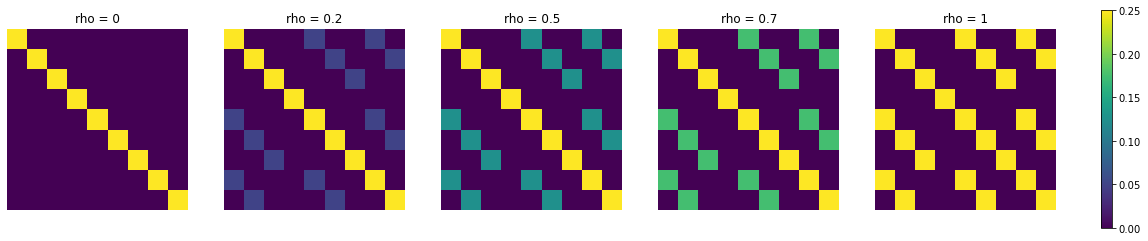

In [112]:
List_rho = [0, 0.2, 0.5, 0.7, 1]

fig, axes = plt.subplots(1, len(List_rho), figsize=(20,4))

for ax, rho in zip(axes, List_rho):
    SigmaP = build_block_cov(sigmas, rho, dims)
    A = SigmaP

    im = ax.imshow(A.numpy(), cmap="viridis")
    ax.set_title(f"rho = {rho}")
    ax.axis("off")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
plt.show()

## General case with MC estimation of the Expectation

In [87]:

def kl_chain_rule_general(w_blocks, sigmas, nus, rho, dims=None):
    """
    Exact KL from your proposition, using the closed-form expectation.
    
    w_blocks : list of tensors [w1, ..., wL]
    sigmas   : list of prior stds [sigma1, ..., sigmaL]
    nus      : list of posterior stds [nu1, ..., nuL]
    rho      : scalar in [0,1)
    dims     : optional list of dimensions
    """
    device = w_blocks[0].device
    dtype = w_blocks[0].dtype
    L = len(w_blocks)

    if dims is None:
        dims = [w.numel() for w in w_blocks]

    kl_total = torch.tensor(0.0, device=device, dtype=dtype)

    for i in range(1, L + 1):
        idx = i - 1
        D_i = dims[idx]
        w_i = w_blocks[idx]
        sigma_i = sigmas[idx]
        nu_i = nus[idx]

        gamma_i, alpha_i = gamma_alpha(i, rho)

        # deterministic mean-shift term:
        # w_i - gamma_i * sum_{j<i} (sigma_i / sigma_j) I_{D_i x D_j} w_j
        mean_shift = w_i.clone()
        for j in range(1, i):
            jdx = j - 1
            D_j = dims[jdx]
            sigma_j = sigmas[jdx]
            w_j = w_blocks[jdx]

            I_ij = rect_identity(D_i, D_j, device=device, dtype=dtype)
            mean_shift = mean_shift - gamma_i * (sigma_i / sigma_j) * (I_ij @ w_j)

        mean_norm_term = mean_shift.pow(2).sum() / (alpha_i * sigma_i**2)

        # variance correction term:
        # D_i * gamma_i^2 * sum_{k,j<i} v_i^(k) v_i^(j) * cov(x_k, x_j)
        # where cov(x_k, x_j) = nu_k^2 if k=j, else rho * nu_k * nu_j
        var_corr = 0.0
        for k in range(1, i):
            kdx = k - 1
            nu_k = nus[kdx]
            sigma_k = sigmas[kdx]
            v_ik = (nu_i / nu_k) - (sigma_i / sigma_k)

            for j in range(1, i):
                jdx = j - 1
                nu_j = nus[jdx]
                sigma_j = sigmas[jdx]
                v_ij = (nu_i / nu_j) - (sigma_i / sigma_j)

                if j == k:
                    cov_kj = nu_k**2
                else:
                    cov_kj = rho * nu_k * nu_j

                var_corr = var_corr + v_ik * v_ij * cov_kj

        var_corr_term = D_i * (gamma_i**2) * var_corr / (alpha_i * sigma_i**2)

        term = 0.5 * (
            D_i * (nu_i**2 / sigma_i**2 - 1.0)
            + mean_norm_term
            + var_corr_term
            + D_i * math.log((sigma_i**2) / (nu_i**2))
        )

        kl_total = kl_total + term

    return kl_total

In [88]:
torch.set_default_dtype(torch.float64)

dims = [4, 3, 2]
rho = 0.3

sigmas = [0.5, 0.8, 1.1]
nus    = [0.6, 0.7, 0.9]

w_blocks = [torch.randn(d) for d in dims]
w = torch.cat(w_blocks, dim=0)

SigmaP = build_block_cov(sigmas, rho, dims)
SigmaQ = build_block_cov(nus, rho, dims)

kl_direct = gaussian_kl_direct(w, SigmaQ, SigmaP)
kl_chain  = kl_chain_rule_general(w_blocks, sigmas, nus, rho, dims)

print("Direct KL =", float(kl_direct))
print("Chain-rule KL =", float(kl_chain))
print("Absolute error =", float(torch.abs(kl_direct - kl_chain)))

Direct KL = 12.446564844034977
Chain-rule KL = 12.446564844034974
Absolute error = 3.552713678800501e-15
